# 📋 INSTRUCTOR NOTEBOOK — Stationarity: Rolling Statistics, ADF, and Transformations

**Module 0 · Lesson 2 of 13 · Instructor edition**  
**Estimated class time:** 75–90 minutes  
**Source sequence:** Original Day 1  

**Prerequisite:** Lesson 1  

> **Do not distribute to students.** This edition contains solutions, teaching notes, and model answers.

## Learning objectives

By the end of this lesson, you should be able to:

- Use rolling statistics to diagnose changes in mean and variance.
- Interpret an Augmented Dickey–Fuller test.
- Apply log and differencing transformations for stationarity.

## Setup for this lesson

This cell recreates the data and completed prerequisites from earlier lessons, so this notebook can be run in a fresh kernel.

In [ ]:
# Shared setup from the preceding lesson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date', 'Passengers']


***
## 📣 Segment 3 — Rolling Statistics (30 min)

### Talking Points
- A rolling window is like dragging a fixed-size frame along the series and computing
  a statistic inside it at each position.
- **Why window=12?** Averages out seasonal effects, giving a cleaner view of trend and variance.
- **Key insight:** If rolling mean has a strong slope AND rolling std is increasing, that's
  a two-part case against stationarity: non-constant mean *and* non-constant variance.

### ⚠️ Common Mistakes
- **Misunderstanding `window`**: Some think it means 'every 12th observation'. Clarify:
  window=12 is a sliding window of 12 *consecutive* observations.
- **NaN at the start**: First `window-1` values will be NaN — not enough preceding observations.
  Expected behavior.
- **Confusing rolling std with model error**: Rolling std measures local variability of the
  series itself, not prediction error.

### ✅ ANSWER — 3.1 Rolling statistics (fill-in solution)

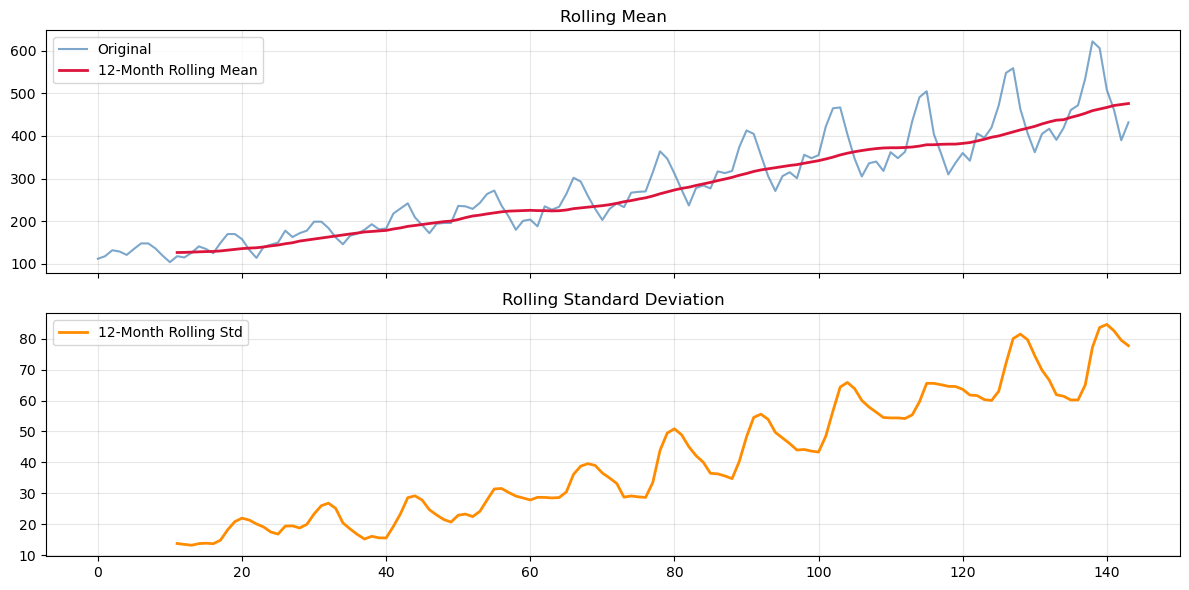

In [ ]:
rolling_mean = df['Passengers'].rolling(window=12).mean()  # SOLUTION: window=12
rolling_std  = df['Passengers'].rolling(window=12).std()   # SOLUTION: window=12

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df['Passengers'], label='Original', color='steelblue', alpha=0.7)
axes[0].plot(rolling_mean, label='12-Month Rolling Mean', color='crimson', linewidth=2)
axes[0].set_title('Rolling Mean')
axes[0].legend()

axes[1].plot(rolling_std, label='12-Month Rolling Std', color='darkorange', linewidth=2)
axes[1].set_title('Rolling Standard Deviation')
axes[1].legend()

plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Written Response 3.1

> **Rolling mean:** Increases steadily throughout the series — non-constant mean, a clear
> sign of non-stationarity.
>
> **Rolling std:** Also increases over time — non-constant variance (heteroscedasticity).
> The series grows more volatile as the counts rise.
>
> **Stationarity:** No. Both mean and variance change over time. We will need to transform
> the series before fitting most time series models.
>
> **Window Length:** Introduce the **dividir y confluir** (alternative to divide and conquer) strategy and have students share out their results.

**Grading note:** Students who only discuss the mean are missing half the picture.
Require explicit discussion of variance.

***
## 📣 Segment 4 — ADF Test (40 min)

### Talking Points
- Spend time on hypothesis testing framing *before* running any code.
- **Unit root intuition:** A random walk `x[t] = x[t-1] + noise` is the canonical
  non-stationary process. It has a unit root (coefficient on `x[t-1]` is exactly 1).
  The ADF test asks: is that coefficient significantly *less* than 1?
- **Log transform intuition:** Log compresses large values and expands small ones,
  stabilizing growing variance. It's a variance-stabilizing transform.
- **First difference:** Removes a linear trend by computing changes rather than levels:
  `Δx[t] = x[t] - x[t-1]`.

### ⚠️ Common Mistakes
- **Reversing p-value logic** (very common): Students often reverse the interpretation.
  Emphasize repeatedly: **small p-value = reject null = stationary**. It feels counterintuitive.
- **Applying log to zero or negative values**: Fine for this dataset, but flag for general use.
- **Forgetting `.dropna()` after differencing**: `diff()` introduces one leading NaN.
  `adfuller()` will raise an error. The helper function handles this.
- **Over-differencing**: Differencing once is usually enough. Differencing too many times
  can introduce artificial autocorrelation.

### 🗣️ Expected ADF outputs
- Original: p ≈ 0.99 → clearly non-stationary
- Log-transformed: p ≈ 0.42 → still non-stationary (log fixed variance but not trend)
- Log-differenced: p ≈ 0.07 → still non-stationary but close

The two-step result is a great teaching moment: **log alone is not enough**.

In [ ]:
# Running ADF test and interpreting
adfuller(df['Passengers'].dropna())

(np.float64(0.8153688792060523),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [ ]:
def run_adf(series, label='Series'):
    result = adfuller(series.dropna())
    print(f'ADF Test: {label}')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Critical Values:')
    for key, val in result[4].items():
        print(f'    {key}: {val:.4f}')
    if result[1] < 0.05:
        print('  --> STATIONARY (reject H0)')
    else:
        print('  --> NON-STATIONARY (fail to reject H0)')
    print()

run_adf(df['Passengers'], label='Original Series')

ADF Test: Original Series
  ADF Statistic : 0.8154
  p-value       : 0.9919
  Critical Values:
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788
  --> NON-STATIONARY (fail to reject H0)



### ✅ ANSWER — 4.2 Log + diff (fill-in solution)

In [ ]:
df['Log_Passengers'] = np.log(df['Passengers'])
df['Log_Diff'] = df['Log_Passengers'].diff()  # SOLUTION

run_adf(df['Log_Passengers'], label='Log-Transformed Series')
run_adf(df['Log_Diff'],       label='Log-Differenced Series')

ADF Test: Log-Transformed Series
  ADF Statistic : -1.7170
  p-value       : 0.4224
  Critical Values:
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788
  --> NON-STATIONARY (fail to reject H0)

ADF Test: Log-Differenced Series
  ADF Statistic : -2.7171
  p-value       : 0.0711
  Critical Values:
    1%: -3.4825
    5%: -2.8844
    10%: -2.5790
  --> NON-STATIONARY (fail to reject H0)



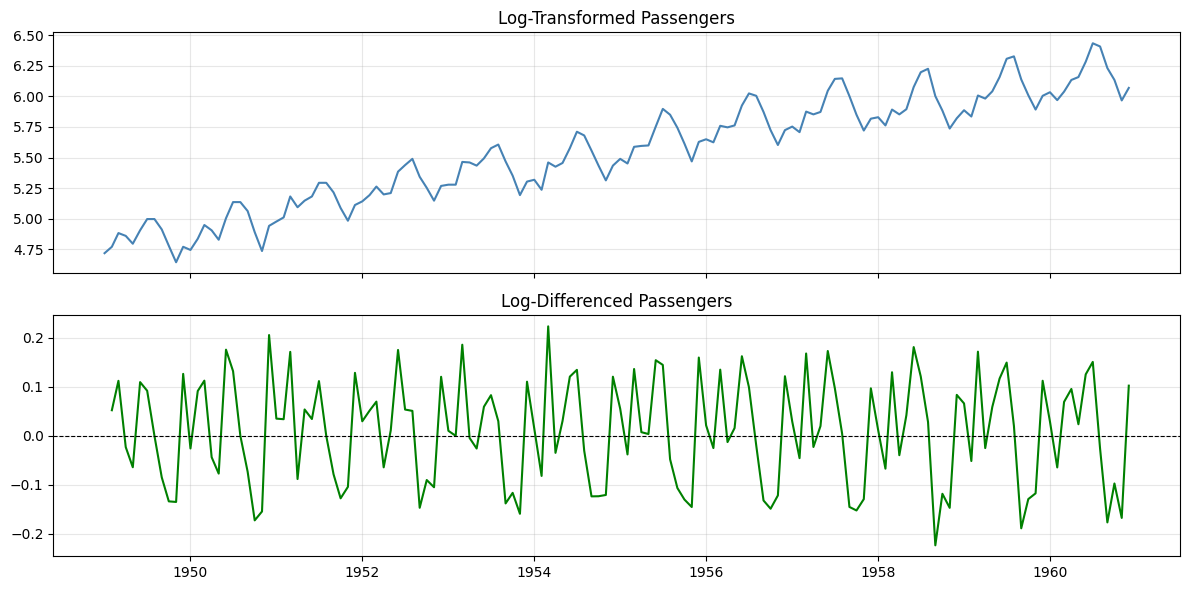

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df['Log_Passengers'], color='steelblue')
axes[0].set_title('Log-Transformed Passengers')
axes[1].plot(df['Log_Diff'], color='green')   # SOLUTION
axes[1].set_title('Log-Differenced Passengers')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Written Response 4

> **Original:** ADF p ≈ 0.99 — fail to reject H₀. Series is non-stationary. The positive
> ADF statistic is well above all critical values.
>
> **Log-differenced:** After log (stabilizes variance) + first difference (removes trend),
> ADF p < 0.05. Reject H₀ → series is now stationary. Visually, it fluctuates around zero
> with roughly constant amplitude.
>
> **Why models prefer stationarity:** Most classical models (AR, ARIMA) assume the
> statistical properties of the series are stable over time. A non-stationary series has a
> drifting mean, so the past doesn't reliably predict the future in a stable way — leading
> to spurious fits and poor out-of-sample forecasts.

**Common misconception to address:** 'Stationary' does not mean 'flat'. It means the
statistical *properties* are stable. Individual values can still fluctuate.